In [115]:
import pandas as pd
df = pd.read_csv('Sentimen_Cleaned.csv')
df.head()

,Response,Submitted on,Kritik dan saran,Sentimen,tanggal,jam,hari,normalisasi,case_folding,tokenizing,filtering,stemming,clean_review,Sentimen_Biner
0,345836,2025-09-21 01:06:00,Untuk servernya full dan error jadi agak susah...,negatif,2025-09-21,1,Sunday,Untuk servernya full dan error jadi agak susah...,untuk servernya full dan error jadi agak susah...,"['untuk', 'servernya', 'full', 'dan', 'error',...","['servernya', 'full', 'error', 'jadi', 'susah'...","['servernya', 'full', 'error', 'jadi', 'susah'...",servernya full error jadi susah kerja,-1
1,306420,2025-09-17 23:02:00,Sudah baik untuk tahun ini namun akan lebih ba...,positif,2025-09-17,23,Wednesday,Sudah baik untuk tahun ini namun akan lebih ba...,sudah baik untuk tahun ini namun akan lebih ba...,"['sudah', 'baik', 'untuk', 'tahun', 'ini', 'na...","['baik', 'tahun', 'lebih', 'baik', 'laksanakan...","['baik', 'tahun', 'lebih', 'baik', 'laksana', ...",baik tahun lebih baik laksana langsung terima ...,1
2,341608,2025-09-20 18:47:00,Tolong perbaiki website PPKMB sehingga lebih m...,positif,2025-09-20,18,Saturday,Tolong perbaiki website PPKMB sehingga lebih m...,tolong perbaiki website ppkmb sehingga lebih m...,"['tolong', 'perbaiki', 'website', 'ppkmb', 'se...","['perbaiki', 'website', 'ppkmb', 'lebih', 'mud...","['baik', 'website', 'ppkmb', 'lebih', 'mudah',...",baik website ppkmb lebih mudah cepat akses,1
3,293208,2025-09-15 20:21:00,Kegiatan PKKMB tahun ini menurut saya sudah be...,positif,2025-09-15,20,Monday,Kegiatan PKKMB tahun ini menurut saya sudah be...,kegiatan pkkmb tahun ini menurut saya sudah be...,"['kegiatan', 'pkkmb', 'tahun', 'ini', 'menurut...","['kegiatan', 'pkkmb', 'tahun', 'berjalan', 'ba...","['giat', 'pkkmb', 'tahun', 'jalan', 'baik', 'b...",giat pkkmb tahun jalan baik beri banyak inform...,1
4,341272,2025-09-20 18:06:00,Semoga lebih baik,positif,2025-09-20,18,Saturday,Semoga lebih baik,semoga lebih baik,"['semoga', 'lebih', 'baik']","['semoga', 'lebih', 'baik']","['moga', 'lebih', 'baik']",moga lebih baik,1


In [116]:
import ast

df = df[['clean_review', 'Sentimen']].copy()
df.columns = ['clean_text', 'label']
df['clean_text'] = df['clean_text'].fillna('').astype(str)

df = df[df['clean_text'].str.split().str.len() > 2].reset_index(drop=True)

print("Shape setelah filter:", df.shape)
print("Label distribution:")
print(df['label'].value_counts())

Shape setelah filter: (7306, 2)
Label distribution:
label
positif    3654
netral     2473
negatif    1179
Name: count, dtype: int64


In [117]:
df.info()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7306 entries, 0 to 7305
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   clean_text  7306 non-null   object
 1   label       7306 non-null   object
dtypes: object(2)
memory usage: 114.3+ KB


,count
label,
positif,3654
netral,2473
negatif,1179


In [118]:
df.isnull().sum()
df.duplicated().sum()

np.int64(156)

Distribusi label:
label
positif    3654
netral     2473
negatif    1179
Name: count, dtype: int64
label
positif    0.500
netral     0.338
negatif    0.161
Name: proportion, dtype: float64

Panjang teks — mean: 11.6, median: 8.0


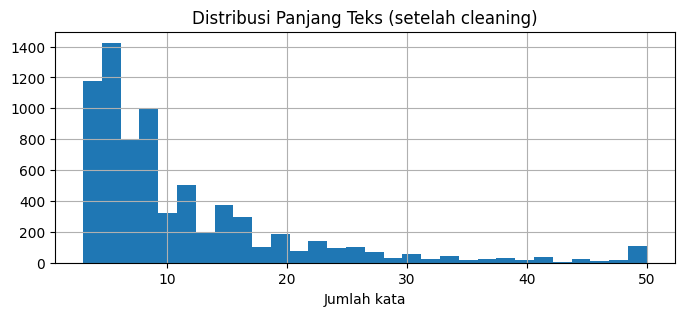

In [119]:
import matplotlib.pyplot as plt

print("Distribusi label:")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True).round(3))

df['text_len'] = df['clean_text'].str.split().str.len()
print(f"\nPanjang teks — mean: {df['text_len'].mean():.1f}, median: {df['text_len'].median()}")

plt.figure(figsize=(8,3))
df['text_len'].clip(upper=50).hist(bins=30)
plt.title('Distribusi Panjang Teks (setelah cleaning)')
plt.xlabel('Jumlah kata')
plt.show()

In [120]:
!pip install Sastrawi

In [121]:
label_map = {'negatif': 0, 'netral': 1, 'positif': 2}
df['label'] = df['label'].map(label_map)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

print("Label distribution (numerik):")
print(df['label'].value_counts().sort_index())

Label distribution (numerik):
label
0    1179
1    2473
2    3654
Name: count, dtype: int64


In [122]:
print("Cek label:")
print(df['label'].value_counts())

Cek label:
label
2    3654
1    2473
0    1179
Name: count, dtype: int64


In [123]:
df['label'].value_counts(normalize=True)

,proportion
label,
2,0.500137
1,0.338489
0,0.161374


In [124]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)

print(f"Train: {len(X_train)}, Val: {len(X_val)}")
print("Train distribution:", y_train.value_counts().sort_index().to_dict())
print("Val distribution:", y_val.value_counts().sort_index().to_dict())

Train: 5844, Val: 1462
Train distribution: {0: 943, 1: 1978, 2: 2923}
Val distribution: {0: 236, 1: 495, 2: 731}


In [125]:
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
_stem_factory = StemmerFactory()
_stemmer = _stem_factory.create_stemmer()

def simple_preprocess_aug(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return _stemmer.stem(text)

In [126]:
import pandas as pd
import re

augmented_data = [
    ("tidak seru sama sekali", 0), ("ga seru acaranya", 0),
    ("kurang seru", 0), ("tidak menarik", 0), ("tidak bagus", 0),
    ("sangat membosankan", 0), ("sangat mengecewakan", 0),
    ("pkkmb tidak seru", 0), ("online jadi tidak seru", 0),
    ("kurang seru karena online", 0), ("benar benar kecewa", 0),
    ("websitenya error terus", 0), ("susah diakses", 0),
    ("sistem eror parah", 0), ("acaranya buruk", 0),
    ("tidak ada manfaat", 0), ("sangat kecewa dengan acara", 0),
    ("tidak nyaman sama sekali", 0), ("materi tidak jelas", 0),
    ("kurang persiapan", 0),
    ("website error terus tidak bisa akses", 0),
    ("server lambat susah kerja", 0),
    ("login susah server down", 0),
    ("web susah diakses saat pkkmb", 0),
    ("tidak bisa masuk sistem", 0),
    ("pkkmb tidak sesuai ekspektasi", 0),
    ("tidak kondusif sama sekali", 0),
    ("tidak efektif dan membuang waktu", 0),
    ("materi tidak arah dan membingungkan", 0),
    ("sulit paham karena tidak jelas", 0),
    ("pkkmb beranta dan tidak terorganisir", 0),
    ("tidak edukatif sama sekali", 0),
    ("sistem pkkmb penuh kendala", 0),
    ("program pkkmb kurang maksimal", 0),
    ("acara tidak profesional dan kacau", 0),
    ("kecewa dengan pelaksanaan pkkmb", 0),
    ("tidak nyaman dan tidak kondusif", 0),
    ("pkkmb molor jauh dari jadwal", 0),
    ("tidak komunikatif dan tidak informatif", 0),
    ("buang waktu tidak ada manfaat", 0),

    ("semoga lebih baik kedepan", 1), ("lebih baik offline", 1),
    ("cukup baik tapi perlu ditingkatkan", 1),
    ("masih ada kekurangan", 1), ("bisa lebih baik lagi", 1),
    ("harap diperbaiki", 1), ("tolong perbaiki sistemnya", 1),
    ("kurang maksimal tapi lumayan", 1),
    ("ada kekurangan sedikit", 1), ("mohon diperbaiki ke depan", 1),
    ("semoga tahun depan lebih baik", 1), ("perlu ditingkatkan lagi", 1),
    ("masukan untuk panitia agar lebih baik", 1),
    ("belum sempurna tapi cukup", 1), ("lumayan bagus ada kekurangan", 1),
    ("kurang seru tapi masih bisa dinikmati", 1),
    ("sedikit kecewa tapi lumayan", 1),
    ("kurang puas dengan hasil pkkmb", 1),
    ("kurang jelas tapi cukup membantu", 1),
    ("online kurang maksimal dibanding offline", 1),
    ("sayang sekali tidak bisa offline", 1),
    ("monoton tapi informatif", 1),

    ("acaranya seru dan menyenangkan", 2), ("sangat bagus terima kasih", 2),
    ("puas dengan acara pkkmb", 2), ("keren dan informatif", 2),
    ("lancar dan menyenangkan", 2), ("sangat bermanfaat bagi mahasiswa baru", 2),
    ("sudah sangat baik", 2), ("terima kasih panitia sudah bekerja keras", 2),
    ("seru banget acaranya", 2), ("semua berjalan dengan baik", 2),
]

aug_texts = [simple_preprocess_aug(t) for t, _ in augmented_data]
aug_labels = [l for _, l in augmented_data]

aug_X = pd.Series(aug_texts)
aug_y = pd.Series(aug_labels)

X_train = pd.concat([X_train, aug_X], ignore_index=True)
y_train = pd.concat([y_train, aug_y], ignore_index=True)

print(f"Training data setelah augmentasi: {len(X_train)}")
print(f"Label distribution:\n{y_train.value_counts().sort_index()}")

Training data setelah augmentasi: 5916
Label distribution:
0     983
1    2000
2    2933
Name: count, dtype: int64


In [127]:
print("Sample clean_text:")
print(df['clean_text'].head(3).tolist())

Sample clean_text:
['servernya full error jadi susah kerja', 'baik tahun lebih baik laksana langsung terima kasih banyak', 'baik website ppkmb lebih mudah cepat akses']


In [128]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

In [129]:
max_vocab = 15000
max_len   = 60

In [130]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

vectorizer = TextVectorization(
    max_tokens=max_vocab,
    output_mode='int',
    output_sequence_length=max_len,
    ngrams=2
)

In [131]:
vectorizer.adapt(X_train)

In [132]:
import json

vocab = vectorizer.get_vocabulary()
print(f"Vocabulary size: {len(vocab)}")
print(f"Contoh 5 kata: {vocab[2:7]}")

vectorizer_export = {
    "config": vectorizer.get_config(),
    "vocabulary": vocab
}

with open("vectorizer_config.json", "w") as f:
    json.dump(vectorizer_export, f)

print("Vectorizer disimpan")

from google.colab import files
files.download("vectorizer_config.json")

Vocabulary size: 15000
Contoh 5 kata: [np.str_('pkkmb'), np.str_('lebih'), np.str_('tidak'), np.str_('giat'), np.str_('sangat')]
Vectorizer disimpan


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [133]:
sample = ["servernya full error"]
vectorizer(sample)

<tf.Tensor: shape=(1, 60), dtype=int64, numpy=
array([[  492,  1349,   188, 12202,     1,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0]])>

In [134]:
X_train_vec = vectorizer(X_train)
X_val_vec = vectorizer(X_val)

In [135]:
X_train_vec.shape

TensorShape([5916, 60])

In [136]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="random_normal",
            trainable=True
        )

        self.b = self.add_weight(
            name="attention_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )

    def call(self, inputs):
        score = tf.nn.tanh(
            tf.tensordot(inputs, self.W, axes=1) + self.b
        )

        attention_weights = tf.nn.softmax(score, axis=1)

        context_vector = attention_weights * inputs
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector

In [137]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=y_train
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights:", class_weights)

class WeightedSparseCCE(tf.keras.losses.Loss):
    def __init__(self, class_weights, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = tf.constant(
            [class_weights[i] for i in sorted(class_weights)],
            dtype=tf.float32
        )

    def call(self, y_true, y_pred):
        cce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        y_true_int = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        sample_weights = tf.gather(self.class_weights, y_true_int)
        return tf.reduce_mean(sample_weights * cce)

    def get_config(self):
        config = super().get_config()
        config.update({"class_weights": {i: float(w) for i, w in enumerate(self.class_weights.numpy())}})
        return config

weighted_loss = WeightedSparseCCE(class_weights)

Class weights: {0: np.float64(2.0061037639877926), 1: np.float64(0.986), 2: np.float64(0.6723491305830208)}


In [138]:
class DetailedLoggingCallback(tf.keras.callbacks.Callback):
    """Custom callback: log per-epoch metrics + deteksi overfitting."""

    def on_train_begin(self, logs=None):
        print("=" * 55)
        print("  Training Dimulai")
        print("=" * 55)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        train_acc = logs.get('accuracy', 0)
        val_acc   = logs.get('val_accuracy', 0)
        train_loss = logs.get('loss', 0)
        val_loss   = logs.get('val_loss', 0)

        gap = train_acc - val_acc
        status = "OVERFIT" if gap > 0.10 else "OK"

        print(f"Epoch {epoch+1:02d} | "
              f"loss: {train_loss:.4f} acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f} val_acc: {val_acc:.4f} | "
              f"gap: {gap:.4f} {status}")

    def on_train_end(self, logs=None):
        print("=" * 55)
        print("  Training Selesai")
        print("=" * 55)

detailed_callback = DetailedLoggingCallback()
print("Custom callback siap digunakan.")

Custom callback siap digunakan.


In [139]:
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers

inputs = tf.keras.Input(shape=(max_len,), name='input_text')

x = layers.Embedding(
    input_dim=max_vocab,
    output_dim=64,
    name='embedding'
)(inputs)

x = layers.SpatialDropout1D(0.3, name='spatial_dropout')(x)

x = layers.Conv1D(64, kernel_size=3, padding='same',
                  activation='relu', name='conv1')(x)
x = layers.Dropout(0.2, name='dropout_conv')(x)
x = layers.Conv1D(64, kernel_size=3, padding='same',
                  activation='relu', name='conv2')(x)

x_att  = AttentionLayer(name='attention')(x)
x_pool = layers.GlobalMaxPooling1D(name='maxpool')(x)
x = layers.Concatenate(name='concat')([x_att, x_pool])

x = layers.Dense(64, activation='relu',
                  kernel_regularizer=regularizers.l2(1e-4),
                  name='dense_1')(x)
x = layers.Dropout(0.5, name='dropout')(x)
outputs = layers.Dense(3, activation='softmax', name='output')(x)

model = Model(inputs=inputs, outputs=outputs, name='sentiment_cnn_attention')
model.summary()

Model: "sentiment_cnn_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_text          │ (None, 60)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 60, 64)    │    960,000 │ input_text[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 60, 64)    │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 60, 64)    │     12,352 │ spatial_dropout[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_conv        │ (None, 60, 64)    │          0 │ conv1[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 60, 64)    │     12,352 │ dropout_conv[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 64)        │        124 │ conv2[0][0]       │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool             │ (None, 64)        │          0 │ conv2[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 128)       │          0 │ attention[0][0],  │
│ (Concatenate)       │                   │            │ maxpool[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        195 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 993,279 (3.79 MB)

 Trainable params: 993,279 (3.79 MB)

 Non-trainable params: 0 (0.00 B)

In [140]:
model.compile(
    loss=weighted_loss,
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    metrics=['accuracy']
)

In [141]:
import os

log_dir = os.path.join("logs", "fit")
os.makedirs(log_dir, exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=3,
        restore_best_weights=True,
        min_delta=0.001,
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=1,
        write_graph=True,
        write_images=False
    ),
    detailed_callback,
]
print(f"TensorBoard logs: {log_dir}")

TensorBoard logs: logs/fit


In [142]:
BATCH_SIZE = 64

train_dataset = tf.data.Dataset.from_tensor_slices((X_train_vec, y_train)) \
    .shuffle(7000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val_vec, y_val)) \
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=25,
    callbacks=callbacks
)

  Training Dimulai
Epoch 1/25
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3241 - loss: 1.1091Epoch 01 | loss: 1.0998 acc: 0.3472 | val_loss: 1.0574 val_acc: 0.5027 | gap: -0.1555 OK
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.3472 - loss: 1.0998 - val_accuracy: 0.5027 - val_loss: 1.0574 - learning_rate: 3.0000e-04
Epoch 2/25
84/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4724 - loss: 1.0536Epoch 02 | loss: 0.9808 acc: 0.4897 | val_loss: 0.8015 val_acc: 0.6142 | gap: -0.1245 OK
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4897 - loss: 0.9808 - val_accuracy: 0.6142 - val_loss: 0.8015 - learning_rate: 3.0000e-04
Epoch 3/25
87/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6142 - loss: 0.7757Epoch 03 | loss: 0.7168 acc: 0.6467 | val_loss: 0.5538 val_acc: 0.7435 | gap: -0.0968 OK
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6467 - loss: 0.7168 - val_accuracy: 0.7435 - val_loss: 0.5538 - learning_rate: 3.0000e-04
Epoch 4/25
82/93 ━━━━━━━━━━━━━━━━

In [143]:
import numpy as np
loss, acc = model.evaluate(X_val_vec, np.array(y_val))
print("Accuracy:", acc)

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8810 - loss: 0.3374
Accuracy: 0.8809849619865417


46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
CLASSIFICATION REPORT
              precision    recall  f1-score   support

     negatif       0.94      0.93      0.93       236
      netral       0.82      0.83      0.83       495
     positif       0.91      0.90      0.90       731

    accuracy                           0.88      1462
   macro avg       0.89      0.89      0.89      1462
weighted avg       0.88      0.88      0.88      1462



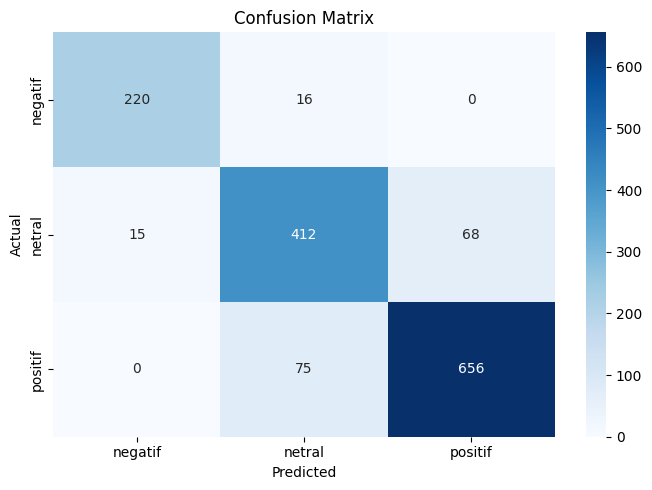

In [144]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_proba = model.predict(X_val_vec)
y_pred = np.argmax(y_pred_proba, axis=1)

label_names = ['negatif', 'netral', 'positif']
print("=" * 55)
print("CLASSIFICATION REPORT")
print("=" * 55)
print(classification_report(y_val, y_pred, target_names=label_names))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

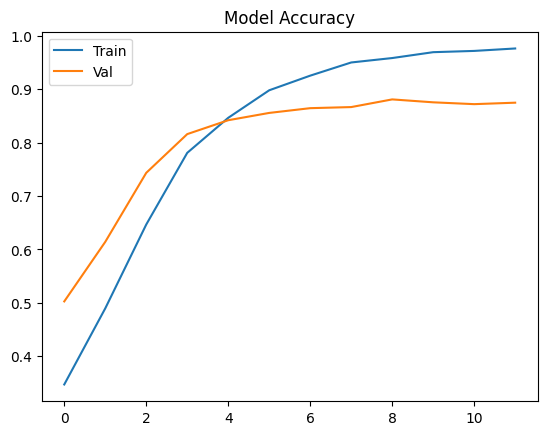

In [145]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Val'])
plt.show()

In [148]:
import numpy as np

inputs_gt = tf.keras.Input(shape=(max_len,), name='input_text')
x_gt = layers.Embedding(input_dim=max_vocab, output_dim=64)(inputs_gt)
x_gt = layers.SpatialDropout1D(0.3)(x_gt)
x_gt = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x_gt)
x_gt_att  = AttentionLayer()(x_gt)
x_gt_pool = layers.GlobalMaxPooling1D()(x_gt)
x_gt = layers.Concatenate()([x_gt_att, x_gt_pool])
x_gt = layers.Dense(64, activation='relu')(x_gt)
x_gt = layers.Dropout(0.5)(x_gt)
outputs_gt = layers.Dense(3, activation='softmax')(x_gt)
model_gt = tf.keras.Model(inputs=inputs_gt, outputs=outputs_gt, name='sentiment_gradienttape')

optimizer_gt = tf.keras.optimizers.Adam(learning_rate=3e-4)
loss_fn      = weighted_loss

train_acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
val_acc_metric   = tf.keras.metrics.SparseCategoricalAccuracy()

BATCH_SIZE_GT = 64
EPOCHS_GT     = 15

best_val_acc_gt  = 0
patience_counter = 0
PATIENCE         = 4

train_ds_gt = tf.data.Dataset.from_tensor_slices((X_train_vec, y_train)) \
    .shuffle(6000).batch(BATCH_SIZE_GT).prefetch(tf.data.AUTOTUNE)
val_ds_gt   = tf.data.Dataset.from_tensor_slices((X_val_vec, y_val)) \
    .batch(BATCH_SIZE_GT).prefetch(tf.data.AUTOTUNE)

print("Memulai custom training loop dengan tf.GradientTape...\n")
history_gt = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(EPOCHS_GT):
    print(f"Epoch {epoch+1}/{EPOCHS_GT}")
    epoch_loss = []

    for x_batch, y_batch in train_ds_gt:
        with tf.GradientTape() as tape:
            y_pred = model_gt(x_batch, training=True)
            loss   = loss_fn(y_batch, y_pred)
        grads = tape.gradient(loss, model_gt.trainable_variables)
        optimizer_gt.apply_gradients(zip(grads, model_gt.trainable_variables))
        train_acc_metric.update_state(y_batch, y_pred)
        epoch_loss.append(loss.numpy())

    train_loss = np.mean(epoch_loss)
    train_acc  = train_acc_metric.result().numpy()
    train_acc_metric.reset_state()

    val_losses = []
    for x_batch, y_batch in val_ds_gt:
        y_pred = model_gt(x_batch, training=False)
        val_losses.append(loss_fn(y_batch, y_pred).numpy())
        val_acc_metric.update_state(y_batch, y_pred)

    val_loss = np.mean(val_losses)
    val_acc  = val_acc_metric.result().numpy()
    val_acc_metric.reset_state()

    history_gt['train_loss'].append(train_loss)
    history_gt['train_acc'].append(train_acc)
    history_gt['val_loss'].append(val_loss)
    history_gt['val_acc'].append(val_acc)

    print(f"  loss: {train_loss:.4f} acc: {train_acc:.4f} | val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

    if val_acc > best_val_acc_gt + 0.001:
        best_val_acc_gt  = val_acc
        patience_counter = 0
        model_gt.save("best_model_gradienttape_checkpoint.keras")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping di epoch {epoch+1}. Best val acc: {best_val_acc_gt:.4f}")
            break

print("\nCustom training loop selesai!")
model_gt = tf.keras.models.load_model(
    "best_model_gradienttape_checkpoint.keras",
    custom_objects={"AttentionLayer": AttentionLayer}
)
print(f"Best val acc GradientTape: {best_val_acc_gt:.4f}")

Memulai custom training loop dengan tf.GradientTape...

Epoch 1/15
  loss: 1.0829 acc: 0.4349 | val_loss: 1.0338 val_acc: 0.6347
Epoch 2/15
  loss: 0.9429 acc: 0.6329 | val_loss: 0.7588 val_acc: 0.6984
Epoch 3/15
  loss: 0.6970 acc: 0.6829 | val_loss: 0.5645 val_acc: 0.7394
Epoch 4/15
  loss: 0.5474 acc: 0.7640 | val_loss: 0.4524 val_acc: 0.8010
Epoch 5/15
  loss: 0.4340 acc: 0.8298 | val_loss: 0.3743 val_acc: 0.8488
Epoch 6/15
  loss: 0.3445 acc: 0.8781 | val_loss: 0.3249 val_acc: 0.8694
Epoch 7/15
  loss: 0.2737 acc: 0.9109 | val_loss: 0.2867 val_acc: 0.8837
Epoch 8/15
  loss: 0.2173 acc: 0.9337 | val_loss: 0.2746 val_acc: 0.8919
Epoch 9/15
  loss: 0.1755 acc: 0.9488 | val_loss: 0.2620 val_acc: 0.8981
Epoch 10/15
  loss: 0.1383 acc: 0.9621 | val_loss: 0.2646 val_acc: 0.9001
Epoch 11/15
  loss: 0.1166 acc: 0.9711 | val_loss: 0.2654 val_acc: 0.9029
Epoch 12/15
  loss: 0.0952 acc: 0.9752 | val_loss: 0.2728 val_acc: 0.9036
Epoch 13/15
  loss: 0.0749 acc: 0.9817 | val_loss: 0.2807 val_acc

In [151]:
import numpy as np

_, acc_fit = model.evaluate(X_val_vec, np.array(y_val), verbose=0)

model_gt.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

_, acc_gt  = model_gt.evaluate(X_val_vec, np.array(y_val), verbose=0)

print(f"\n=== PERBANDINGAN MODEL ===")
print(f"model.fit      → val_acc: {acc_fit:.4f}")
print(f"GradientTape   → val_acc: {acc_gt:.4f}")

best_model = model_gt if acc_gt > acc_fit else model
nama_model = 'GradientTape' if acc_gt > acc_fit else 'model.fit'
print(f"Model yang diekspor: {nama_model}")

best_model.save("final_model.keras")
best_model.export("saved_model/sentiment_model")

loaded = tf.saved_model.load("saved_model/sentiment_model")
print("SavedModel berhasil di-load")

import os, shutil
shutil.make_archive("saved_model_folder", "zip", "saved_model")
print("Zip selesai")

from google.colab import files
files.download("final_model.keras")
files.download("saved_model_folder.zip")


=== PERBANDINGAN MODEL ===
model.fit      → val_acc: 0.8810
GradientTape   → val_acc: 0.9029
Model yang diekspor: GradientTape
Saved artifact at 'saved_model/sentiment_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60), dtype=tf.float32, name='input_text')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132779939435280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132779939436240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132779939434704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132779939440080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132779939437776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132779939434512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132779939432784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132779939436816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132779939437008: TensorSpe

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [152]:
import re
import numpy as np
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

_factory  = StopWordRemoverFactory()
_all_sw   = set(_factory.get_stop_words())
_keep     = {
    'tidak','tak','bukan','tanpa','jangan','belum',
    'sangat','sekali','banget','amat','terlalu','lebih',
    'kurang','cukup','agak','lumayan',
    'baik','bagus','buruk','jelek','enak','susah','mudah',
    'senang','puas','kecewa','nyaman','aman','bahaya',
    'seru','membosankan','menarik','membingungkan',
    'cepat','lambat','lancar','error','gagal','berhasil',
    'perlu','harus','bisa','mampu','sulit',
    'semoga','harap','tolong','mohon',
}
_stopwords_inf = _all_sw - _keep

import pandas as pd
_df_slang = pd.read_excel('Slangword-indonesian.xlsm', engine='openpyxl')
_df_slang = _df_slang.drop_duplicates(subset='slang', keep='first')
_df_slang['slang']  = _df_slang['slang'].str.lower().str.strip()
_df_slang['formal'] = _df_slang['formal'].str.lower().str.strip()
_slang_dict = dict(zip(_df_slang['slang'], _df_slang['formal']))
_slang_dict.update({
    "ga":"tidak","gak":"tidak","gk":"tidak","ngga":"tidak",
    "nggak":"tidak","enggak":"tidak","engga":"tidak",
    "kagak":"tidak","kaga":"tidak","bgt":"banget",
    "yg":"yang","dgn":"dengan","utk":"untuk","krn":"karena",
    "sdh":"sudah","blm":"belum","jg":"juga","lg":"lagi",
    "tp":"tapi","gpp":"tidak apa","mksh":"terima kasih","tks":"terima kasih",
})

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
_stem_factory_inf = StemmerFactory()
_stemmer_inf = _stem_factory_inf.create_stemmer()

def _preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = ' '.join([_slang_dict.get(w, w) for w in text.split()])
    text = ' '.join([w for w in text.split() if w not in _stopwords_inf])
    text = _stemmer_inf.stem(text)
    return text

def predict_sentiment(text: str) -> dict:
    cleaned    = _preprocess(text)
    vectorized = vectorizer([cleaned])
    proba      = best_model.predict(vectorized, verbose=0)[0]
    label_idx  = int(np.argmax(proba))
    mapping    = {0: "negatif", 1: "netral", 2: "positif"}
    return {
        "input_asli"  : text,
        "teks_bersih" : cleaned,
        "sentimen"    : mapping[label_idx],
        "confidence"  : f"{proba[label_idx]*100:.2f}%",
        "probabilitas": {
            "negatif": f"{proba[0]*100:.2f}%",
            "netral" : f"{proba[1]*100:.2f}%",
            "positif": f"{proba[2]*100:.2f}%",
        }
    }

import pprint
pprint.pprint(predict_sentiment("acaranya seru dan sangat menyenangkan"))
pprint.pprint(predict_sentiment("servernya error terus, sangat mengecewakan"))
pprint.pprint(predict_sentiment("ga seru"))
pprint.pprint(predict_sentiment("tidak menarik sama sekali"))
pprint.pprint(predict_sentiment("Biasa aja sih, ga ada yang spesial"))

{'confidence': '99.93%',
 'input_asli': 'acaranya seru dan sangat menyenangkan',
 'probabilitas': {'negatif': '0.00%', 'netral': '0.07%', 'positif': '99.93%'},
 'sentimen': 'positif',
 'teks_bersih': 'acara seru sangat senang'}
{'confidence': '99.43%',
 'input_asli': 'servernya error terus, sangat mengecewakan',
 'probabilitas': {'negatif': '99.43%', 'netral': '0.57%', 'positif': '0.00%'},
 'sentimen': 'negatif',
 'teks_bersih': 'servernya error terus sangat kecewa'}
{'confidence': '79.65%',
 'input_asli': 'ga seru',
 'probabilitas': {'negatif': '18.85%', 'netral': '79.65%', 'positif': '1.50%'},
 'sentimen': 'netral',
 'teks_bersih': 'tidak seru'}
{'confidence': '81.13%',
 'input_asli': 'tidak menarik sama sekali',
 'probabilitas': {'negatif': '81.13%', 'netral': '18.85%', 'positif': '0.03%'},
 'sentimen': 'negatif',
 'teks_bersih': 'tidak tarik sama sekali'}
{'confidence': '76.07%',
 'input_asli': 'Biasa aja sih, ga ada yang spesial',
 'probabilitas': {'negatif': '1.76%', 'netral': '7

In [153]:
import tensorflow as tf
import os, shutil
from google.colab import files

log_dir = os.path.join("logs", "fit")
os.makedirs(log_dir, exist_ok=True)

writer = tf.summary.create_file_writer(log_dir)
with writer.as_default():
    for i in range(len(history_gt['train_acc'])):
        tf.summary.scalar("epoch_accuracy",     history_gt['train_acc'][i],  step=i)
        tf.summary.scalar("epoch_val_accuracy", history_gt['val_acc'][i],    step=i)
        tf.summary.scalar("epoch_loss",         history_gt['train_loss'][i], step=i)
        tf.summary.scalar("epoch_val_loss",     history_gt['val_loss'][i],   step=i)
    writer.flush()

print("TensorBoard logs dibuat")

shutil.make_archive("tensorboard_logs", "zip", "logs")
files.download("tensorboard_logs.zip")
files.download("vectorizer_config.json")

TensorBoard logs dibuat


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [154]:
!pip freeze > requirements.txt